# **Book-level regime throttle**

**Mechanics:** Run the FCF quality book only when a market trend rule holds (default: SPY above its 200-day SMA). When the rule fails, cut equity to cash **or** rotate into a defensive Halal sleeve. The 10% name cap from paper 08 stays on.

**White-paper focus:** Use dual-momentum-style *regime* logic as a whole-NAV drawdown brake. Do not use it as a third stock-picking sleeve.

Paper 07 showed that 20% dual momentum inside a blend does not change 2022 and then misses 2023. Paper 08 locked the engine as **FCF 100% + 10% name cap**. This notebook puts the SPY trend rule on **100% of NAV** and asks three questions:

1. Always-on FCF versus SMA-to-cash (true always-on this time: `throttle="off"`).
2. Faster switches (50-day, 100-day, 12-month SPY trend, 5-day re-entry delay) versus the 200-day SMA. The 200-day rule is late in 2020.
3. Cash versus a defensive Halal sleeve while the switch is off. Defensive = FCF names in consumer defensive, healthcare, or utilities, cap-weighted, 10% name cap. If that list is thinner than 10 names, use the lowest-vol third of the FCF book.

**Frozen:** FCF live rule, AAOIFI screens, `name_cap=0.10`, 2% risk-free, train 2020–2022 / test 2023–2024.

**Not in this book:** ROIC mix, SUE satellite, dual momentum as a 20% sleeve weight.

**Kill-style reading (same as paper 07 search):**

- 2022 more than 5 points worse than SPUS → fail.
- Train max drawdown worse than always-on FCF by a large margin is not the issue (the brake should *improve* it). Fail if train max drawdown is **worse than SPUS**.
- Test: 2023 more than 15 points worse than always-on FCF → fail (too expensive).

**White-paper question:** is the live brake “SPY 200-day → cash”, a faster SMA → cash, or 200-day → defensive Halal sleeve?


## Setup

Reuse paper 07 metrics and prices. Engine is FCF only.


In [1]:
import os
import subprocess
import sys
from pathlib import Path

from IPython.display import display


def resolve_notebook_dir() -> Path:
    candidates = [Path.cwd()]
    candidates.append(
        Path.home() / "Documents/Development/Monterey-Finance/Research/papers/09-regime-throttle"
    )
    for path in candidates:
        try:
            resolved = path.resolve()
        except OSError:
            continue
        if resolved.is_dir() and (resolved / "code.ipynb").exists():
            return resolved
    return Path.cwd()


NB_DIR = resolve_notebook_dir()
os.chdir(NB_DIR)

REPO_ROOT = NB_DIR.parents[2]
RESEARCH_ROOT = NB_DIR.parents[1]
PAPER07 = RESEARCH_ROOT / "papers" / "07-book-construction"
HQ_ROOT = REPO_ROOT.parent / "halalquant"
PIP_DEPS = ["matplotlib", "pyarrow", "duckdb"]

if HQ_ROOT.is_dir() and (HQ_ROOT / "pyproject.toml").exists():
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-e", f"{HQ_ROOT}[cache]"],
        cwd=str(NB_DIR),
        check=False,
    )
    if str(HQ_ROOT) not in sys.path:
        sys.path.insert(0, str(HQ_ROOT))
subprocess.run([sys.executable, "-m", "pip", "install", "-q"] + PIP_DEPS, cwd=str(NB_DIR), check=False)
if str(RESEARCH_ROOT) not in sys.path:
    sys.path.insert(0, str(RESEARCH_ROOT))

import importlib
import sleeves
import sleeves.backtest
import sleeves.book
import sleeves.lab
import sleeves.select

importlib.reload(sleeves.backtest)
importlib.reload(sleeves.select)
importlib.reload(sleeves.book)
importlib.reload(sleeves.lab)
importlib.reload(sleeves)

os.environ.setdefault(
    "HALALQUANT_SEC_UA",
    "Monterey Finance Research halalquant/0.1.0 research@montereyfinance.com",
)

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sleeves import FrozenRules, Lab, calc_performance_stats
from sleeves.backtest import holdings_to_weights, run_weight_schedule
from sleeves.prices import spy_sma_risk_on, trailing_volatility
from sleeves.triggers import rebalance_dates
from sleeves.universe import apply_sector_screen, load_sp500_tickers
from sleeves.weighting import apply_name_cap, assign_cap_weights

warnings.filterwarnings("ignore", category=FutureWarning)

START = "2019-12-19"
END = "2024-12-31"
TRAIN_START, TRAIN_END = "2020-01-01", "2022-12-31"
TEST_START, TEST_END = "2023-01-01", "2024-12-31"
RISK_FREE_RATE = 0.02
NAME_CAP = 0.10
ENGINE = {"fcf_quality": 1.0}
KILL_2022_GAP = 0.05
KILL_2023_GAP = 0.15
BENCHMARKS = {"S&P 500": "SPY", "Halal (SPUS)": "SPUS"}
DEFENSIVE_KEYS = ("defensive", "staple", "healthcare", "health care", "utilities", "utility")

CACHE_DIR = PAPER07 / "cache"
FIG_DIR = NB_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"notebook dir: {NB_DIR}")
print(f"engine: FCF 100%  name_cap={NAME_CAP:.0%}  throttle tests on full NAV")



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip


notebook dir: /Users/raoabdul/Documents/Development/Monterey-Finance/Research/papers/09-regime-throttle
engine: FCF 100%  name_cap=10%  throttle tests on full NAV


## Step 1 — Load the lab


In [2]:
metrics = pd.read_parquet(CACHE_DIR / "metrics.parquet")
prices = pd.read_parquet(CACHE_DIR / "prices.parquet")
prices["date"] = pd.to_datetime(prices["date"])

raw = load_sp500_tickers()
eligible, _, sector_map = apply_sector_screen(raw)
print(f"metrics {metrics.shape}  prices {prices.shape}  sector map {len(sector_map)}")

rules = FrozenRules().with_book(
    sleeve_weights=ENGINE,
    name_cap=NAME_CAP,
    throttle="off",
    collapse_share_classes=True,
    cost_bps=10,
    risk_free_rate=RISK_FREE_RATE,
    rebalance_freq="ME",
)
lab = Lab.from_frames(metrics, prices, rules=rules, start=START, end=END)

bench_px = (
    prices[prices["symbol"].isin(BENCHMARKS.values())]
    .pivot(index="date", columns="symbol", values="adj_close")
    .sort_index()
    .ffill()
)
bench_ret = bench_px.pct_change(fill_method=None)
spy = bench_ret["SPY"].dropna()
spus = bench_ret["SPUS"].dropna()
spy = spy[(spy.index >= pd.Timestamp(START)) & (spy.index <= pd.Timestamp(END))]
spus = spus[(spus.index >= pd.Timestamp(START)) & (spus.index <= pd.Timestamp(END))]
print("Lab ready.")


metrics (25600, 21)  prices (778360, 8)  sector map 502
Lab ready.


## Step 2 — FCF schedule and defensive schedule

Build month-end weights **once**. Regime tests only change when those weights are on, in cash, or swapped for the defensive list.


In [3]:
def is_defensive_sector(sector) -> bool:
    s = str(sector or "").lower()
    return any(k in s for k in DEFENSIVE_KEYS)


def cap_weights(holds: pd.DataFrame) -> pd.Series:
    if holds is None or holds.empty:
        return pd.Series(dtype=float)
    w = holdings_to_weights(holds)
    return apply_name_cap(w, NAME_CAP)


eval_dates = [d for d in rebalance_dates(metrics) if pd.Timestamp(d) >= pd.Timestamp(START)]
print(f"Rebalance dates: {len(eval_dates)}")

fcf_w = {}
def_w = {}
for as_of in eval_dates:
    holds = lab.holdings("fcf_quality", as_of)
    fcf_w[as_of] = cap_weights(holds)
    if holds.empty:
        def_w[as_of] = pd.Series(dtype=float)
        continue
    work = holds.copy()
    work["sector"] = work["symbol"].map(sector_map)
    defensive = work[work["sector"].map(is_defensive_sector)].copy()
    if len(defensive) < 10:
        vol = trailing_volatility(lab.price_panel(), as_of, lookback=252)
        work = work.copy()
        work["vol"] = work["symbol"].map(vol)
        n = max(10, int(np.ceil(len(work) / 3)))
        defensive = work.nsmallest(n, "vol")
    if "weight" in defensive.columns:
        defensive = assign_cap_weights(defensive)
    def_w[as_of] = cap_weights(defensive)

print(
    "Sample last FCF names",
    0 if fcf_w[eval_dates[-1]].empty else len(fcf_w[eval_dates[-1]]),
    "defensive",
    0 if def_w[eval_dates[-1]].empty else len(def_w[eval_dates[-1]]),
)


Rebalance dates: 61
Sample last FCF names 121 defensive 25


## Step 3 — Regime series

Each series is daily True = FCF book on. False = cash or defensive.


In [4]:
spy_px = lab.spy_series()
idx = spy_px.index
idx = idx[(idx >= pd.Timestamp(START)) & (idx <= pd.Timestamp(END))]


def sma_on(window: int) -> pd.Series:
    return pd.Series(
        [spy_sma_risk_on(spy_px, dt, window) for dt in idx],
        index=pd.to_datetime(idx),
        dtype=bool,
    )


def spy_12m_on() -> pd.Series:
    lagged = spy_px.shift(252)
    raw = spy_px > lagged
    return raw.reindex(idx).fillna(False)


def hysteresis_on(raw: pd.Series, days_to_enter: int = 5) -> pd.Series:
    """Leave as soon as the SMA fails. Re-enter only after N days above."""
    out = []
    invested = False
    streak = 0
    for val in raw.astype(bool):
        if val:
            streak += 1
        else:
            streak = 0
            invested = False
        if streak >= days_to_enter:
            invested = True
        out.append(invested)
    return pd.Series(out, index=raw.index, dtype=bool)


regimes = {
    "SMA 50": sma_on(50),
    "SMA 100": sma_on(100),
    "SMA 200": sma_on(200),
    "SPY 12-month trend": spy_12m_on(),
    "SMA 200 + 5d re-entry": hysteresis_on(sma_on(200), 5),
}

for name, s in regimes.items():
    flips = int((s.astype(int).diff().abs() == 1).sum())
    print(f"{name:24s}  risk-on {s.mean():6.1%}  flips {flips:3d}")


SMA 50                    risk-on  72.8%  flips  79
SMA 100                   risk-on  76.2%  flips  42
SMA 200                   risk-on  78.0%  flips  30
SPY 12-month trend        risk-on  78.0%  flips  18
SMA 200 + 5d re-entry     risk-on  74.6%  flips  13


## Step 4 — Score every throttle


In [5]:
def sl(s, a, b):
    return s[(s.index >= pd.Timestamp(a)) & (s.index <= pd.Timestamp(b))].dropna()


def calendar_return(s, year):
    x = sl(s, f"{year}-01-01", f"{year}-12-31")
    return float((1 + x).prod() - 1) if not x.empty else np.nan


def to_series(frame):
    s = frame.dropna(subset=["return"]).set_index("date")["return"].astype(float)
    s.index = pd.to_datetime(s.index)
    return s.sort_index()


def n_flips(reg: pd.Series) -> int:
    return int((reg.astype(int).diff().abs() == 1).sum())


def score(s: pd.Series, label: str, regime: pd.Series | None, off_mode: str) -> dict:
    full = sl(s, START, END)
    train = sl(s, TRAIN_START, TRAIN_END)
    test = sl(s, TEST_START, TEST_END)
    st = calc_performance_stats(full, label, rf=RISK_FREE_RATE)
    st_tr = calc_performance_stats(train, label, rf=RISK_FREE_RATE)
    st_te = calc_performance_stats(test, label, rf=RISK_FREE_RATE)
    cash_frac = np.nan if regime is None else float((~regime.reindex(full.index, method="ffill").fillna(True)).mean())
    return {
        "book": label,
        "off_mode": off_mode,
        "ret_2020": calendar_return(s, 2020),
        "ret_2022": calendar_return(s, 2022),
        "ret_2023": calendar_return(s, 2023),
        "ret_2024": calendar_return(s, 2024),
        "full_cagr": st["CAGR"],
        "full_vol": st["Volatility"],
        "full_sharpe": st["Sharpe"],
        "full_max_dd": st["Max Drawdown"],
        "full_calmar": st["Calmar"],
        "train_max_dd": st_tr["Max Drawdown"],
        "train_calmar": st_tr["Calmar"],
        "test_cagr": st_te["CAGR"],
        "test_max_dd": st_te["Max Drawdown"],
        "days_off": cash_frac,
        "flips": n_flips(regime) if regime is not None else 0,
    }


print("Running always-on FCF + 10% cap …")
always_df = run_weight_schedule(lab.prices, fcf_w, start=START, throttle_on=None)
always = to_series(always_df)
series_map = {"Always-on FCF (10% cap)": always}

rows = [score(always, "Always-on FCF (10% cap)", None, "invested")]
for rname, regime in regimes.items():
    for off_mode, off_sched in (("cash", None), ("defensive", def_w)):
        if rname != "SMA 200" and off_mode == "defensive" and rname not in {"SMA 100", "SMA 200"}:
            continue
        if off_mode == "defensive" and rname not in {"SMA 200", "SMA 100"}:
            continue
        label = f"{rname} → {off_mode}"
        print(f"Running {label} …", flush=True)
        ret = run_weight_schedule(
            lab.prices,
            fcf_w,
            start=START,
            throttle_on=regime,
            off_weights_by_date=off_sched,
        )
        s = to_series(ret)
        series_map[label] = s
        rows.append(score(s, label, regime, off_mode))

for name, s in (("S&P 500", spy), ("Halal (SPUS)", spus)):
    rows.append(score(s, name, None, "benchmark"))
    series_map[name] = s

table = pd.DataFrame(rows)
fcf_row = table.loc[table["book"] == "Always-on FCF (10% cap)"].iloc[0]
spus_row = table.loc[table["book"] == "Halal (SPUS)"].iloc[0]


def kill_reason(row) -> str:
    if row["off_mode"] == "benchmark":
        return ""
    reasons = []
    if pd.notna(row["ret_2022"]) and pd.notna(spus_row["ret_2022"]):
        if row["ret_2022"] < spus_row["ret_2022"] - KILL_2022_GAP:
            reasons.append("2022 >5ppt worse than SPUS")
    if row["book"] != fcf_row["book"] and pd.notna(row["train_max_dd"]) and pd.notna(spus_row["train_max_dd"]):
        if row["train_max_dd"] < spus_row["train_max_dd"]:
            reasons.append("train max DD worse than SPUS")
    if pd.notna(row["ret_2023"]) and pd.notna(fcf_row["ret_2023"]):
        if row["ret_2023"] < fcf_row["ret_2023"] - KILL_2023_GAP:
            reasons.append("2023 >15ppt worse than always-on FCF")
    return "; ".join(reasons)


table["kill"] = table.apply(kill_reason, axis=1)
table["pass"] = table["kill"] == ""
show = table.copy()
for c in (
    "ret_2020", "ret_2022", "ret_2023", "ret_2024",
    "full_cagr", "full_vol", "full_max_dd", "train_max_dd", "test_cagr", "test_max_dd", "days_off",
):
    show[c] = show[c].map(lambda x: f"{x:.1%}" if pd.notna(x) else "—")
for c in ("full_sharpe", "full_calmar", "train_calmar"):
    show[c] = show[c].map(lambda x: f"{x:.2f}" if pd.notna(x) else "—")
display(show[["book", "off_mode", "ret_2020", "ret_2022", "ret_2023", "ret_2024",
              "full_cagr", "full_vol", "full_max_dd", "full_calmar", "days_off", "flips", "pass", "kill"]])
table.to_csv(NB_DIR / "regime_results.csv", index=False)
print("Wrote regime_results.csv")


Running always-on FCF + 10% cap …
Running SMA 50 → cash …
Running SMA 100 → cash …
Running SMA 100 → defensive …
Running SMA 200 → cash …
Running SMA 200 → defensive …
Running SPY 12-month trend → cash …
Running SMA 200 + 5d re-entry → cash …


,book,off_mode,ret_2020,ret_2022,ret_2023,ret_2024,full_cagr,full_vol,full_max_dd,full_calmar,days_off,flips,pass,kill
0,Always-on FCF (10% cap),invested,24.9%,-22.9%,33.0%,22.8%,15.4%,21.8%,-29.5%,0.52,—,0,True,
1,SMA 50 → cash,cash,48.9%,20.8%,42.8%,33.5%,38.0%,13.0%,-7.7%,4.93,27.3%,79,True,
2,SMA 100 → cash,cash,33.6%,15.2%,37.8%,26.3%,29.3%,13.3%,-8.6%,3.42,23.9%,42,True,
3,SMA 100 → defensive,defensive,26.0%,-0.9%,26.1%,23.6%,20.6%,19.5%,-26.2%,0.79,23.9%,42,True,
4,SMA 200 → cash,cash,32.2%,1.0%,39.5%,22.8%,24.4%,13.8%,-9.0%,2.70,22.2%,30,True,
5,SMA 200 → defensive,defensive,21.6%,-9.3%,35.4%,22.8%,19.0%,19.4%,-27.1%,0.70,22.2%,30,True,
6,SPY 12-month trend → cash,cash,17.2%,-12.0%,18.7%,22.8%,14.4%,15.6%,-18.9%,0.76,22.2%,18,True,
7,SMA 200 + 5d re-entry → cash,cash,18.3%,-11.8%,21.7%,22.8%,15.3%,13.1%,-13.7%,1.11,25.3%,13,True,
8,S&P 500,benchmark,18.3%,-18.2%,26.2%,25.3%,14.7%,20.9%,-33.7%,0.44,—,0,True,
9,Halal (SPUS),benchmark,25.7%,-22.8%,34.2%,27.7%,17.8%,21.6%,-30.8%,0.58,—,0,True,


Wrote regime_results.csv


## Step 5 — Paths


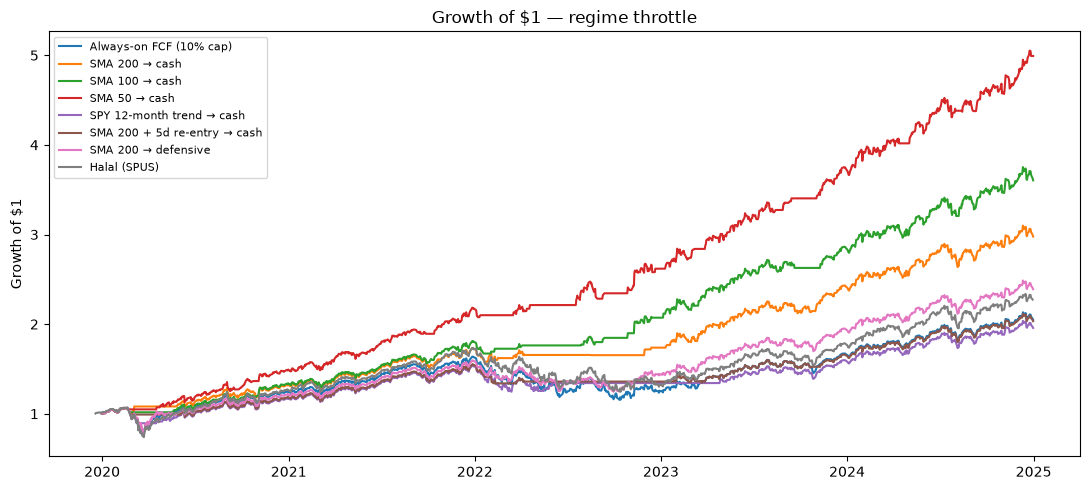

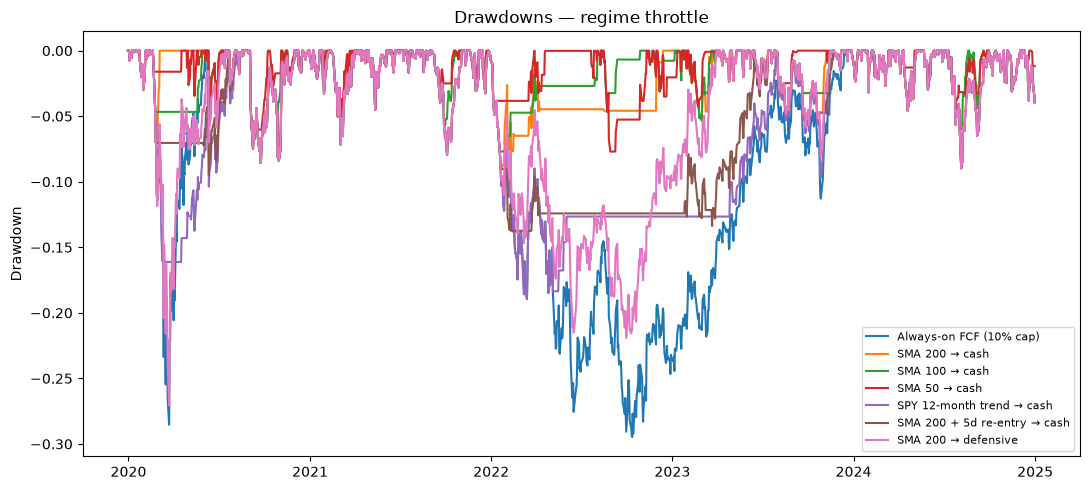

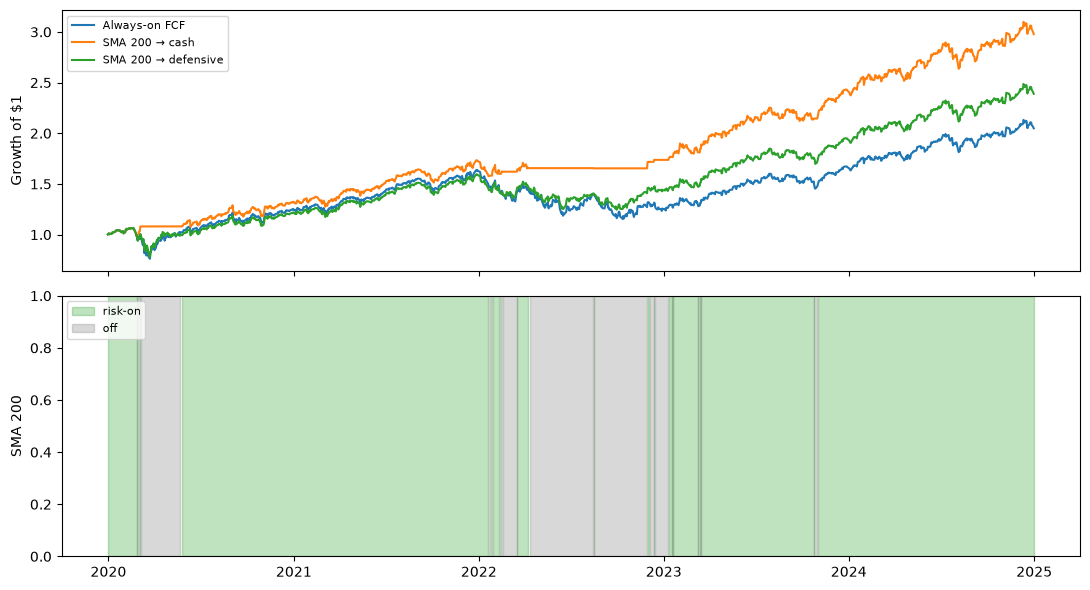

In [6]:
plot_keys = [
    "Always-on FCF (10% cap)",
    "SMA 200 → cash",
    "SMA 100 → cash",
    "SMA 50 → cash",
    "SPY 12-month trend → cash",
    "SMA 200 + 5d re-entry → cash",
    "SMA 200 → defensive",
    "Halal (SPUS)",
]
plot_keys = [k for k in plot_keys if k in series_map]

fig, ax = plt.subplots(figsize=(11, 5))
for k in plot_keys:
    eq = (1 + sl(series_map[k], START, END)).cumprod()
    ax.plot(eq.index, eq.values, label=k)
ax.set_title("Growth of $1 — regime throttle")
ax.set_ylabel("Growth of $1")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "equity-curves.png", dpi=140)
plt.show()

fig, ax = plt.subplots(figsize=(11, 5))
for k in plot_keys:
    if k == "Halal (SPUS)":
        continue
    eq = (1 + sl(series_map[k], START, END)).cumprod()
    dd = eq / eq.cummax() - 1
    ax.plot(dd.index, dd.values, label=k)
ax.set_title("Drawdowns — regime throttle")
ax.set_ylabel("Drawdown")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "drawdowns.png", dpi=140)
plt.show()

reg200 = regimes["SMA 200"].reindex(sl(always, START, END).index, method="ffill")
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
eq_on = (1 + sl(always, START, END)).cumprod()
eq_200 = (1 + sl(series_map["SMA 200 → cash"], START, END)).cumprod()
eq_def = (1 + sl(series_map["SMA 200 → defensive"], START, END)).cumprod()
axes[0].plot(eq_on.index, eq_on.values, label="Always-on FCF")
axes[0].plot(eq_200.index, eq_200.values, label="SMA 200 → cash")
axes[0].plot(eq_def.index, eq_def.values, label="SMA 200 → defensive")
axes[0].legend(fontsize=8)
axes[0].set_ylabel("Growth of $1")
axes[1].fill_between(reg200.index, 0, 1, where=reg200.values, color="tab:green", alpha=0.3, label="risk-on")
axes[1].fill_between(reg200.index, 0, 1, where=~reg200.fillna(False).values, color="tab:gray", alpha=0.3, label="off")
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=8, loc="upper left")
axes[1].set_ylabel("SMA 200")
fig.tight_layout()
fig.savefig(FIG_DIR / "sma200-cash-vs-defensive.png", dpi=140)
plt.show()


## Step 6 — Pick


In [8]:
cands = table[(table["off_mode"] != "benchmark") & (table["book"] != "Always-on FCF (10% cap)") & table["pass"]]
print("Always-on FCF is the no-brake control. Candidates that passed kill rules:")
if cands.empty:
    print("No throttle passed. Keep always-on FCF (the brake failed the 2023 cost test or 2022).")
    pick = table.loc[table["book"] == "Always-on FCF (10% cap)"].iloc[0]
    why = "no regime rule passed; do not ship a brake that fails the frozen kills"
else:
    display(cands[["book", "ret_2022", "ret_2023", "train_max_dd", "train_calmar", "full_max_dd", "full_calmar", "days_off", "flips"]])
    pick = cands.sort_values("train_calmar", ascending=False).iloc[0]
    why = "highest train Calmar among throttles that passed 2022 vs SPUS and 2023 vs always-on FCF"

days_off = pick["days_off"]
days_off_txt = "—" if pd.isna(days_off) else f"{days_off:.1%}"
print("\nPAPER 09 PICK:", pick["book"])
print(" ", why)
print(
    f"  2022 {pick['ret_2022']:.1%}  2023 {pick['ret_2023']:.1%}  "
    f"full DD {pick['full_max_dd']:.1%}  Calmar {pick['full_calmar']:.2f}  "
    f"days off {days_off_txt}"
)


Always-on FCF is the no-brake control. Candidates that passed kill rules:


,book,ret_2022,ret_2023,train_max_dd,train_calmar,full_max_dd,full_calmar,days_off,flips
1,SMA 50 → cash,0.208188,0.427953,-0.076973,4.898767,-0.076973,4.932169,0.273233,79
2,SMA 100 → cash,0.152211,0.377769,-0.085552,3.198365,-0.085552,3.420351,0.239079,42
3,SMA 100 → defensive,-0.009281,0.260786,-0.262016,0.674511,-0.262016,0.785558,0.239079,42
4,SMA 200 → cash,0.009699,0.394804,-0.090376,2.225206,-0.090376,2.700712,0.221604,30
5,SMA 200 → defensive,-0.092705,0.353583,-0.270548,0.470758,-0.270548,0.704000,0.221604,30
6,SPY 12-month trend → cash,-0.120201,0.187097,-0.189420,0.538984,-0.189420,0.759804,0.221604,18
7,SMA 200 + 5d re-entry → cash,-0.117784,0.217372,-0.137409,0.776612,-0.137409,1.110510,0.252581,13



PAPER 09 PICK: SMA 50 → cash
  highest train Calmar among throttles that passed 2022 vs SPUS and 2023 vs always-on FCF
  2022 20.8%  2023 42.8%  full DD -7.7%  Calmar 4.93  days off 27.3%


## How to read the pick

- **Always-on** is the control. It is not the mandate winner if a throttle cuts max drawdown without failing 2023.
- **SMA 200 → cash** is the paper 08 live brake. It should remain unless a faster rule improves 2020 *and* still passes 2023.
- **SMA 50 / 100** are the 2020-lag tests. More flips. Fail if 2023 is more than 15 points below always-on FCF.
- **12-month SPY trend** is absolute dual momentum on the index, not a stock sort.
- **5-day re-entry** only delays *entry*. Exit stays immediate when the SMA fails.
- **Defensive sleeve** must beat cash in 2022 to justify the extra names. If it tracks FCF, it is not defensive.

Live rule after this notebook: FCF 100%, `name_cap=0.10`, plus the picked throttle (`spy_sma` window and cash vs defensive).
